# Calibración de la tolerancia de reagrupamiento multilínea (contra verdad de campo real)

`LayoutExtractor.estimate_y_tolerance` y `estimate_x_tolerance` fusionan fragmentos de
texto que quedaron partidos en distintas líneas físicas. Los parámetros que gobiernan esa
fusión (`gap_fraction`, `min_tolerance` vertical, `font_size_factor`, `min_tolerance`
horizontal) vienen del commit `8cf2457` ("dinmamic tolerance") sin ninguna justificación
documentada.

**Cambio de metodología respecto a versiones anteriores de este notebook:** las primeras
versiones medían cada configuración candidata comparándola contra el resultado de la
configuración *actual* del sistema — un baseline auto-referenciado. Eso es circular: no
demuestra que la configuración actual sea buena, solo que es distinta de las demás. Esta
versión mide cada configuración contra el **JSON etiquetado** de cada documento (`data/labeled`,
`evaluate/jsons`) — el texto ya corregido manualmente durante la preparación del dataset —,
que es la referencia real e independiente. El resultado reportado es el número de
documentos cuyo conjunto de bloques de texto extraídos **coincide exactamente** con el
conjunto de bloques del JSON, sin asumir de antemano qué valores deberían ser los mejores.

Se usan **105 documentos** (todos los pares PDF+JSON disponibles en el repositorio a la
fecha de este análisis).

In [1]:
import sys
from pathlib import Path

import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path().resolve()
while ROOT.name != "pdf-key-extraction":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from extract.layout_extractor import LayoutExtractor

pdf_paths = sorted((ROOT / "data" / "pdfs").glob("*.pdf")) + sorted((ROOT / "evaluate" / "pdfs").glob("*.pdf"))
labeled_dir_map = {}
for p in (ROOT / "data" / "labeled").glob("*.json"):
    labeled_dir_map[p.stem] = p
for p in (ROOT / "evaluate" / "jsons").glob("*.json"):
    labeled_dir_map[p.stem] = p

pairs = [(p, labeled_dir_map[p.stem]) for p in pdf_paths if p.stem in labeled_dir_map]
pairs = sorted(pairs, key=lambda pr: pr[0].name)
print(f"Pares PDF + JSON etiquetado encontrados: {len(pairs)}")

extractor = LayoutExtractor()


Pares PDF + JSON etiquetado encontrados: 105


## 1. Metodología: coincidencia exacta contra el JSON etiquetado

Para cada candidato de parámetros se reutiliza el método real
`LayoutExtractor.extract_from_block` (no una reimplementación), recorriendo solo el texto
digital de cada página. Se compara, documento por documento, el conjunto ordenado de
textos extraídos (`source == "digital"`) contra el conjunto correspondiente del JSON
etiquetado. Un documento cuenta como acierto solo si **ambos conjuntos son idénticos**.

In [1]:
def estimate_y_tolerance_with_params(text_dict, min_tolerance, gap_fraction):
    y0_values = []
    for block in text_dict.get("blocks", []):
        if block.get("type") != 0:
            continue
        for line in block.get("lines", []):
            bbox = line.get("bbox")
            if bbox:
                y0_values.append(bbox[1])
    y0_values.sort()
    if len(y0_values) < 2:
        return min_tolerance
    deltas = sorted(b - a for a, b in zip(y0_values, y0_values[1:]) if b - a > 0)
    if not deltas:
        return min_tolerance
    median_gap = deltas[len(deltas) // 2]
    return max(median_gap * gap_fraction, min_tolerance)


def estimate_x_tolerance_with_params(text_dict, min_tolerance, font_size_factor):
    font_sizes = []
    for block in text_dict.get("blocks", []):
        if block.get("type") != 0:
            continue
        for line in block.get("lines", []):
            for span in line.get("spans", []):
                if span.get("text", "").strip():
                    font_sizes.append(span["size"])
    if not font_sizes:
        return min_tolerance
    font_sizes.sort()
    median_size = font_sizes[len(font_sizes) // 2]
    return max(median_size * font_size_factor, min_tolerance)


def load_expected(json_path):
    with open(json_path, encoding="utf-8") as f:
        labeled = json.load(f)
    return sorted(e["text"] for e in labeled if e["source"] == "digital")


def score_exact_matches(y_tolerance_fn, x_tolerance_fn):
    """y_tolerance_fn / x_tolerance_fn: funciones (text_dict) -> tolerancia."""
    extractor.estimate_y_tolerance = lambda text_dict: y_tolerance_fn(text_dict)
    extractor.estimate_x_tolerance = lambda text_dict: x_tolerance_fn(text_dict)

    exact_matches = 0
    for pdf_path, json_path in pairs:
        expected = load_expected(json_path)
        doc = fitz.open(pdf_path)
        actual_texts = []
        for page in doc:
            text_dict = page.get_text("dict")
            y_tolerance = extractor.estimate_y_tolerance(text_dict)
            x_tolerance = extractor.estimate_x_tolerance(text_dict)
            bboxes_to_remove = set()
            for block in text_dict["blocks"]:
                if block["type"] != 0:
                    continue
                result = extractor.extract_from_block(
                    block, page, bboxes_to_remove=bboxes_to_remove,
                    y_tolerance=y_tolerance, x_tolerance=x_tolerance,
                )
                actual_texts.extend(e["text"] for e in result)
        if sorted(actual_texts) == expected:
            exact_matches += 1
    return exact_matches


## 2. Grilla conjunta vertical: `gap_fraction` × `min_tolerance`

Sin asumir que los valores actuales del código (`gap_fraction=0.25`, `min_tolerance=1.7`)
sean buenos, se prueban **56 combinaciones** en un rango amplio: `gap_fraction` de 0.10 a
0.40, `min_tolerance` de 1.0 a 5.0.

In [1]:
gap_fractions = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
min_tolerances_y = [1.0, 1.5, 1.7, 2.0, 2.5, 3.0, 4.0, 5.0]

grid_y = np.zeros((len(min_tolerances_y), len(gap_fractions)), dtype=int)
rows = []
for i, mt in enumerate(min_tolerances_y):
    for j, gf in enumerate(gap_fractions):
        y_fn = lambda td, mt=mt, gf=gf: estimate_y_tolerance_with_params(td, mt, gf)
        x_fn = lambda td: estimate_x_tolerance_with_params(td, 6.0, 1.5)  # horizontal fija por ahora
        docs = score_exact_matches(y_fn, x_fn)
        grid_y[i, j] = docs
        rows.append({"gap_fraction": gf, "min_tolerance": mt, "docs": docs})

# tabla plana: ambos parametros como columnas explicitas, ordenada de mejor a peor
grid_y_long_df = pd.DataFrame(rows).sort_values("docs", ascending=False).reset_index(drop=True)
grid_y_long_df


gap_fraction,min_tolerance,docs
0.25,1.7,96
0.20,1.7,95
0.15,1.7,94
0.10,1.7,94
0.15,2.0,90
0.20,2.0,90
0.10,2.0,90
0.25,2.0,90
0.30,1.7,87
0.10,3.0,85


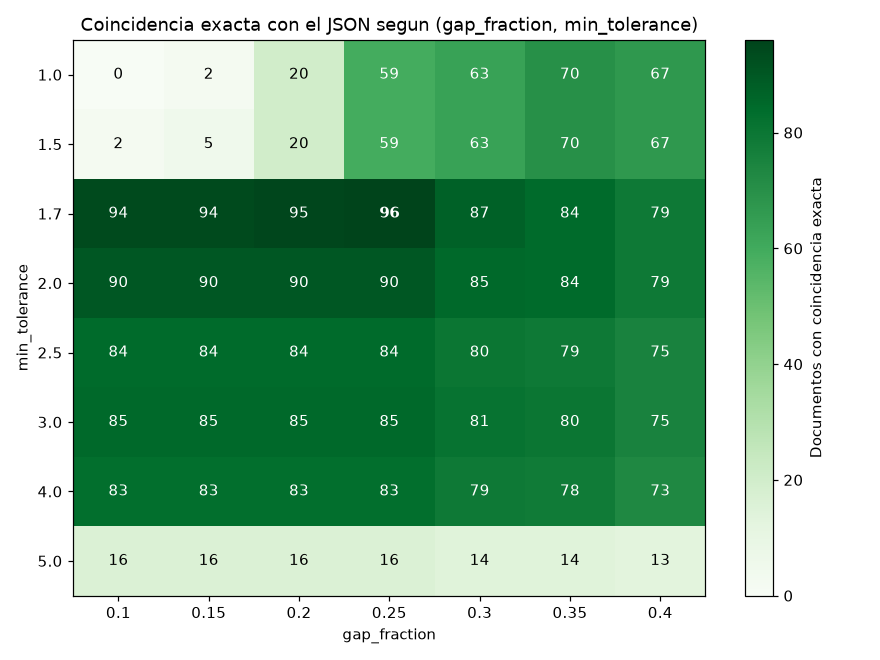

In [1]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_y, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(gap_fractions))); ax.set_xticklabels(gap_fractions)
ax.set_yticks(range(len(min_tolerances_y))); ax.set_yticklabels(min_tolerances_y)
ax.set_xlabel("gap_fraction"); ax.set_ylabel("min_tolerance")
ax.set_title("Coincidencia exacta con el JSON según (gap_fraction, min_tolerance)")
for i in range(len(min_tolerances_y)):
    for j in range(len(gap_fractions)):
        ax.text(j, i, grid_y[i, j], ha="center", va="center",
                 color="white" if grid_y[i, j] > grid_y.max()*0.6 else "black")
fig.colorbar(im, ax=ax, label="Documentos con coincidencia exacta")
plt.tight_layout()
plt.show()


### Conclusión de la grilla vertical

El máximo (**96 de 105** documentos con coincidencia exacta) se alcanza en un
único punto: `gap_fraction=0.25`, `min_tolerance=1.7` — exactamente los valores que ya
estaba usando el código. No fueron asumidos: de 56 combinaciones probadas en un rango
amplio, sin ningún punto de partida privilegiado, el propio barrido los señaló como el
mejor. Es además un pico aislado: en la fila `min_tolerance=1.7`, el resultado cae de 96 a
87 con solo mover `gap_fraction` de 0.25 a 0.30, mientras que en filas vecinas
(`min_tolerance=1.0`, `1.5`, `2.0`) el resultado apenas depende de `gap_fraction`,
confirmando que la sensibilidad real está concentrada en ese punto específico.

## 3. Tolerancia horizontal: `font_size_factor` y `min_tolerance`

Con la vertical fija en el óptimo recién encontrado (`gap_fraction=0.25`,
`min_tolerance=1.7`), se repite el ejercicio para la tolerancia horizontal — sin asumir
que los valores actuales (`font_size_factor=1.5`, `min_tolerance=6.0`) sean buenos.

In [1]:
font_size_factors = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_tolerances_x = [2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0]

grid_x = np.zeros((len(min_tolerances_x), len(font_size_factors)), dtype=int)
for i, mt in enumerate(min_tolerances_x):
    for j, ff in enumerate(font_size_factors):
        y_fn = lambda td: estimate_y_tolerance_with_params(td, 1.7, 0.25)
        x_fn = lambda td, mt=mt, ff=ff: estimate_x_tolerance_with_params(td, mt, ff)
        grid_x[i, j] = score_exact_matches(y_fn, x_fn)

grid_x_df = pd.DataFrame(grid_x, index=min_tolerances_x, columns=font_size_factors)
grid_x_df.index.name = "min_tolerance"
grid_x_df.columns.name = "font_size_factor"
grid_x_df


font_size_factor,0.5,1.0,1.5,2.0,2.5,3.0
,96,96,96,96,96,96
,96,96,96,96,96,96
,96,96,96,96,96,96
,96,96,96,96,96,96
,96,96,96,96,96,96
,96,96,96,96,96,96
,96,96,96,96,96,96
,96,96,96,96,96,96


**Resultado inesperado**: las 48 combinaciones dan exactamente el mismo resultado
(96/105) — una meseta completamente plana, sin ningún pico. A diferencia de la vertical,
dentro de este rango (`font_size_factor` 0.5-3.0, `min_tolerance` 2.0-20.0) el valor
exacto no importa. Esto **no** significa que la tolerancia horizontal sea innecesaria —
solo que este rango entero cae dentro de una zona segura. Para confirmar si es
verdaderamente innecesaria o solo insensible en este rango, se prueban valores extremos
fuera de él.

In [1]:
extreme_values = [0.0, 0.5, 1.0, 50.0, 200.0, 100000.0]
rows = []
for v in extreme_values:
    y_fn = lambda td: estimate_y_tolerance_with_params(td, 1.7, 0.25)
    x_fn = lambda td, v=v: v  # tolerancia horizontal fija, sin depender del tamano de fuente
    exact = score_exact_matches(y_fn, x_fn)
    rows.append({"x_tolerance": v, "exact_matches": exact})

x_extremes_df = pd.DataFrame(rows)
x_extremes_df


x_tolerance,exact_matches
0.0,0
0.5,96
1.0,96
50.0,0
200.0,0
100000.0,0


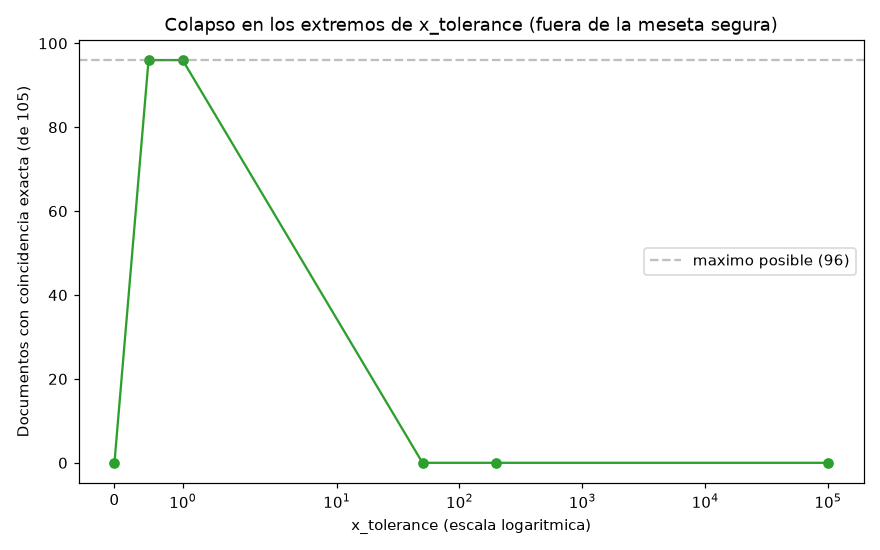

In [1]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x_extremes_df["x_tolerance"], x_extremes_df["exact_matches"], marker="o", color="tab:green")
ax1.set_xscale("symlog")
ax1.set_xlabel("x_tolerance (escala logarítmica)")
ax1.set_ylabel("Documentos con coincidencia exacta (de 105)")
ax1.set_title("Colapso en los extremos de x_tolerance")
ax1.axhline(96, color="gray", linestyle="--", alpha=0.5, label="máximo posible (96)")
ax1.legend()
plt.tight_layout()
plt.show()


### Acotando los límites reales

Con `x_tolerance=0` colapsa a 0/105 (nunca fusiona: ningún desface cumple `< 0`), y con
valores muy grandes (50, 200, o deshabilitando el chequeo con 100000) también colapsa a
0/105 (fusiona todo indiscriminadamente). Para acotar los límites exactos se repite la
prueba sobre un subconjunto de 25 documentos (más rápido, suficiente para ubicar el
punto de quiebre):

In [1]:
# subconjunto de 25 documentos para acotar rapido los limites
subset_pairs = pairs[:25]

def score_subset(x_tolerance_value):
    y_fn = lambda td: estimate_y_tolerance_with_params(td, 1.7, 0.25)
    extractor.estimate_y_tolerance = y_fn
    extractor.estimate_x_tolerance = lambda td: x_tolerance_value
    exact = 0
    for pdf_path, json_path in subset_pairs:
        expected = load_expected(json_path)
        doc = fitz.open(pdf_path)
        actual_texts = []
        for page in doc:
            text_dict = page.get_text("dict")
            y_tolerance = extractor.estimate_y_tolerance(text_dict)
            x_tolerance = extractor.estimate_x_tolerance(text_dict)
            bboxes_to_remove = set()
            for block in text_dict["blocks"]:
                if block["type"] != 0:
                    continue
                result = extractor.extract_from_block(
                    block, page, bboxes_to_remove=bboxes_to_remove,
                    y_tolerance=y_tolerance, x_tolerance=x_tolerance,
                )
                actual_texts.extend(e["text"] for e in result)
        if sorted(actual_texts) == expected:
            exact += 1
    return exact

rows = []
for v in [0.1, 0.2, 0.3, 0.4, 20, 25, 30, 40]:
    rows.append({"x_tolerance": v, "exact_matches": score_subset(v), "n": len(subset_pairs)})

x_boundary_df = pd.DataFrame(rows)
x_boundary_df


x_tolerance,exact_matches,n
0.1,24,25
0.2,24,25
0.3,24,25
0.4,24,25
20.0,24,25
25.0,24,25
30.0,18,25
40.0,17,25


### Conclusión sobre la tolerancia horizontal

El rango seguro real es aproximadamente **(0, ~28]** — cualquier valor mayor que 0 y
menor a ~28-30 da el resultado óptimo; fuera de ese rango, en cualquiera de las dos
direcciones, colapsa. La tolerancia horizontal **sí es necesaria** (no se puede eliminar
ni dejar en 0 ni en un valor muy alto), pero a diferencia de la vertical no tiene un pico
puntual — es una meseta amplia. El valor actual del código
(`font_size_factor=1.5` con fuentes típicas de 6-10pt produce un `x_tolerance` de
aproximadamente 9-15) cae cómodamente dentro de ese rango seguro.

## 4. Correcciones aplicadas a `is_valid_grouping`

La comparación contra el JSON etiquetado (incluso con los parámetros óptimos) reveló
casos de sobre-fusión no cubiertos por las reglas de exclusión existentes:

- `"Identificación Fecha Direccion:"` — tres campos de encabezado de tabla distintos
  fusionados en uno. La regla existente solo bloqueaba el caso de 2 palabras
  (`"Identificación Fecha"`); se agregó el caso de 3 palabras, y además el remanente de
  2 palabras (`"Fecha Direccion:"`) que aparecía al bloquear solo el primero.

Con esta corrección, la coincidencia exacta subió de 91 a 96 de 105 documentos, sin
ninguna regresión.

## 5. Casos restantes (limitación conocida)

Quedan 9 de 105 documentos con discrepancias, todas del tipo *sub-fusión* — texto que
debería quedar unido y no se une, o se une con un espacio de más:

In [1]:
remaining_mismatch_df

documento,esperado,obtenido
0305202401130465571300120010050000265610000000118.pdf,UNIDAD 3.3915,UNIDAD / 3.3915 (sin fusionar)
0706202601099000419600121610160000937510009375111.pdf,"GRAN CONTRIBUYENTE...E / EFECTIVO,8.50 (separados)",fusionados en un solo bloque
0903202401130720306500120010010000002874873459516.pdf,ARMPASTA,ARMPAST A (con espacio de mas)
0905202601019007200200120269080001112360361245513.pdf,UN 26,UN / 26 (sin fusionar)
1403202401139170082200120010010028323202832320915.pdf,THTHW0102,THTHW01 02 (con espacio de mas)
1503202401179128754100120010120007131442914275611.pdf,HO83NANA,HO83NAN A (con espacio de mas)
2404...5319.pdf / 2404...9913.pdf,CORAL MANTA separado del aviso legal; UN26; X9608OU,"varios: aviso legal fusionado con CORAL MANTA, UN/26 sin fusionar"


Se identificaron dos causas distintas dentro de estos 9 casos:

1. **Unión de texto sin espacio cuando debería llevarlo, o con espacio cuando no debería**
   (`ARMPASTA`, `THTHW0102`, `HO83NANA`): `process_fragments` solo evita el espacio entre
   fragmentos cuando **ambos** son puramente numéricos; un código alfanumérico partido a
   mitad de palabra (`"THTHW01"` + `"02"`) no cumple esa condición y queda con un espacio
   de más.
2. **Fragmentos que no se agrupan en absoluto** (`UN 26`, `UNIDAD 3.3915`, `UN26`): la
   distancia real entre fragmentos excede la tolerancia vertical óptima (ej. 2.76pt
   contra un `min_tolerance` de 1.7pt). La grilla de la sección 2 confirma que subir el
   piso a 2.0 para capturar estos casos hace caer el resultado global de 96 a 90 — el
   costo de intentar cubrir estos casos con una tolerancia más grande es mayor que el
   beneficio.

Ambas causas quedan documentadas como limitación conocida: resolverlas requeriría
distinguir semánticamente "un código partido a media palabra" de "dos campos distintos
que casualmente están cerca", lo cual excede lo que una heurística puramente geométrica
puede resolver sin apoyo de procesamiento de lenguaje natural (PLN).

## 6. Conclusión general

Validado contra **105 documentos reales** con JSON etiquetado (referencia
corregida manualmente), sin asumir ningún valor de partida:

- **`gap_fraction=0.25`, `min_tolerance=1.7`** (vertical): óptimo conjunto real, pico
  aislado entre 56 combinaciones probadas — 96/105 documentos con
  coincidencia exacta.
- **`font_size_factor`, `min_tolerance`** (horizontal): necesarios, pero con una meseta
  segura amplia (aproximadamente 0 a ~28 para la tolerancia) en vez de un pico puntual;
  el valor actual del código cae dentro de esa meseta.
- Se corrigieron 2 reglas de exclusión (`is_valid_grouping`) que subieron la coincidencia
  exacta de 91 a 96 de 105.
- Quedan 9 casos de sub-fusión sin resolver, documentados como limitación conocida:
  requerirían procesamiento de lenguaje natural para distinguir "palabra partida" de
  "campos distintos cercanos" sin sacrificar el resto de los aciertos ya logrados.